# Predicting Antibacterial Activity Against E. coli Using Molecular Descriptors

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## Objective

Predict the antibacterial inhibition rate against E. coli (INHIB_AVE) using a combination of molecular descriptors computed from small-molecule SMILES data (for example: molecular weight, logP, TPSA) and experimental features extracted directly from the CO-ADD dataset (for example: INHIB_STD, NASSAYS, DMAX_AVE, MIC-derived features). Our models learn to predict the continuous inhibition percentage directly from these features. We train and compare three classical ML regression models.

# Basic Data Preview

Read CO-ADD CSV files with pandas and preview the first rows using `head()`.

CO-ADD provides two CSV files because they serve different purposes:
- `InhibitionData` contains single-concentration inhibition results (good for quick screening).
- `DoseResponseData` contains multi-concentration dose-response results (better for detailed potency analysis).

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pylab
import scipy.stats as stats
import statsmodels.api as sm
import tensorflow as tf
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, silhouette_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.cluster import KMeans
from pyclustering.utils.metric import * 
from nltk.cluster.kmeans import KMeansClusterer
from sklearn.svm import SVC

2026-05-08 23:44:45.487409: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---
This sets the folder and file paths for the two CO-ADD CSV files.
- `DATA_DIR` points to the folder containing the data.
- `INHIB_PATH` and `DOSE_PATH` build the full path to each CSV file using `Path` / operator.

In [2]:
DATA_DIR = Path("CO-ADD_r03.02-2020_CSV")
INHIB_PATH = DATA_DIR / "CO-ADD_InhibitionData_r03_01-02-2020_CSV.csv"
DOSE_PATH = DATA_DIR / "CO-ADD_DoseResponseData_r03_01-02-2020_CSV.csv"

---

## Open Inhibition data CSV file

In [3]:
# There are two CSV files in the CO-ADD folder.
# For now, we will open the InhibitionData file.

df = pd.read_csv(INHIB_PATH, low_memory=False)
print(df.head())

   Unnamed: 0        COADD_ID  COMPOUND_CODE COMPOUND_NAME     PROJECT_ID  \
0           0  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
1           1  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
2           2  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
3           3  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   
4           4  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   

                          LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  Russian Academy of Science (Russia)   GN_046         Escherichia coli   
1  Russian Academy of Science (Russia)   GN_049         Escherichia coli   
2  Russian Academy of Science (Russia)   GP_020    Staphylococcus aureus   
3  Russian Academy of Science (Russia)   FG_001         Candida albicans   
4  Russian Academy of Science (Russia)   FG_002  Cryptococcus neoformans   

             STRAIN  NASSAYS  INHIB_AVE  INHIB_STD      CONC  \
0      lpxC; MB4

---
## Open the other CO-ADD file (DoseResponseData)

In [4]:
# Open the other CO-ADD file (DoseResponseData)
df2 = pd.read_csv(DOSE_PATH, low_memory=False)
print(df2.head())

   Unnamed: 0        COADD_ID COMPOUND_CODE COMPOUND_NAME  \
0           0  CO-ADD:0136135    0367428:01           NaN   
1           1  CO-ADD:0136135    0367428:01           NaN   
2           2  CO-ADD:0136135    0367428:01           NaN   
3           3  CO-ADD:0136135    0367428:01           NaN   
4           4  CO-ADD:0136135    0367428:01           NaN   

                                   SMILES     PROJECT_ID  \
0  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
1  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
2  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
3  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
4  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   

                      LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  NIH/NCI (USA) - Diversity Set V   MA_007             Homo sapiens   
1  NIH/NCI (USA) - Diversity Set V   GP_020    Staphylococcus aureus   
2  NIH/NCI (USA) - Diversity Set V   GN_042   Pseudomona

---
The below cell reads the two CO-ADD CSV files into pandas DataFrames and prints basic information about them.
- `shape` shows the number of rows and columns in each file.
- `columns.tolist()` lists the column names so you can see what data fields are available.
This helps verify the files loaded correctly and shows what information each dataset contains.

In [5]:
df_inhib = pd.read_csv(INHIB_PATH, low_memory=False)
df_dose = pd.read_csv(DOSE_PATH, low_memory=False)

print("InhibitionData shape:", df_inhib.shape)
print("DoseResponseData shape:", df_dose.shape)

print("\nInhibitionData columns:")
print(df_inhib.columns.tolist())

print("\nDoseResponseData columns:")
print(df_dose.columns.tolist())

InhibitionData shape: (802918, 14)
DoseResponseData shape: (42209, 15)

InhibitionData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES']

DoseResponseData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'SMILES', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


In [6]:
ORGANISM_COL = "ORGANISM"
ECOLI_NAME = "Escherichia coli"
EXACT_KEYS = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Find E. coli rows in inhibition data
mask_inhib = df_inhib[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

# Find E. coli rows in dose-response data
mask_dose = df_dose[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

ecoli_inhib = df_inhib.loc[mask_inhib].copy()
ecoli_dose = df_dose.loc[mask_dose].copy()

# Diagnostic counts: compound-level overlap and exact experiment-level overlap.
overlap_ids = set(ecoli_inhib["COADD_ID"]).intersection(ecoli_dose["COADD_ID"])
inhib_exact_keys = set(map(tuple, ecoli_inhib[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
dose_exact_keys = set(map(tuple, ecoli_dose[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
overlap_exact_keys = inhib_exact_keys.intersection(dose_exact_keys)

print(f"E. coli inhibition rows: {len(ecoli_inhib):,}")
print(f"E. coli dose-response rows: {len(ecoli_dose):,}")
print(f"Overlapping COADD_ID values: {len(overlap_ids):,}")
print(f"Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): {len(overlap_exact_keys):,}")
print(f"Unique E. coli inhibition strains: {ecoli_inhib['STRAIN'].nunique()}")
print(f"Unique E. coli dose-response strains: {ecoli_dose['STRAIN'].nunique()}")

E. coli inhibition rows: 237,752
E. coli dose-response rows: 4,711
Overlapping COADD_ID values: 4,174
Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): 4,268
Unique E. coli inhibition strains: 3
Unique E. coli dose-response strains: 4


---
We will use all the strains of E. coli for this project. This means we are not excluding any specific E. coli variant from the initial analysis, so the data will reflect the full diversity of E. coli strains present in the CO-ADD datasets. This helps us get a broad view of how E. coli responds overall before we decide whether to compare individual strains later.

---
## Create a simple merged E. coli DataFrame

We match the two CSV files using `COADD_ID`, `STRAIN`, and `ASSAY_ID` so the inhibition and dose-response values come from the same E. coli experiment. This gives us 4268 exact-matched rows across 4174 unique compounds while keeping the existing columns and only adding the non-overlapping columns from the dose-response file.


In [7]:
# Use COADD_ID + STRAIN + ASSAY_ID so the rows refer to the same exact experiment.
exact_keys = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Remove rows missing the merge keys or SMILES, and keep one row per exact match key.
def keep_exact_rows(df):
    return (
        df
        .dropna(subset=exact_keys + ["SMILES"])
        .drop_duplicates(subset=exact_keys)
        .reset_index(drop=True)
    )

ecoli_inhib_exact = keep_exact_rows(ecoli_inhib)
ecoli_dose_exact = keep_exact_rows(ecoli_dose)

# Find the columns that appear only in the dose-response table.
# The exact match keys are excluded because they are already used for the merge.
dose_only_cols = [
    col for col in ecoli_dose_exact.columns
    if col not in ecoli_inhib_exact.columns and col not in exact_keys
]

# Merge the two cleaned tables into one exact-match DataFrame.
# Keep all columns from the inhibition table and add only new columns from the dose-response table.
ecoli_merged_df = pd.merge(
    ecoli_inhib_exact,
    ecoli_dose_exact[exact_keys + dose_only_cols],
    on=exact_keys,
    how="inner"
)
ecoli_merged_df = ecoli_merged_df.drop(columns=["Unnamed: 0"])

print("Merged E. coli DataFrame shape:", ecoli_merged_df.shape)
print("Unique COADD_ID values:", ecoli_merged_df["COADD_ID"].nunique())
print("Added columns from dose-response file:\n", dose_only_cols)
print(ecoli_merged_df.columns.tolist())

ecoli_merged_df.head()

Merged E. coli DataFrame shape: (4268, 17)
Unique COADD_ID values: 4174
Added columns from dose-response file:
 ['DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']
['COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


,COADD_ID,COMPOUND_CODE,COMPOUND_NAME,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,CONC,SMILES,DRVAL_TYPE,DRVAL_MEDIAN,DRVAL_UNIT,DMAX_AVE
0,CO-ADD:0227615,A0877/0041139,NaN,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,32 ug/mL,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,MIC,>32,ug/mL,6.85
1,CO-ADD:0231316,A0969/0045283,NaN,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,32 ug/mL,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,MIC,>32,ug/mL,10.35
2,CO-ADD:0166443,A0501/0023282,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,80 ug/mL,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,MIC,>32,uM,9.15
3,CO-ADD:0166253,A0494/0022904,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,80 ug/mL,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,MIC,>32,uM,1.65
4,CO-ADD:0215273,A0528/0024455,NaN,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,32 ug/mL,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,MIC,>32,ug/mL,-13.30


In [8]:
ecoli_merged_df.isna().sum().sort_values(ascending=False)

# Might need to drop some columns before moving on 
# Also need to convert to same units for some columns (e.g. MIC values) before doing any analysis.

COMPOUND_NAME    4177
COADD_ID            0
INHIB_AVE           0
DRVAL_UNIT          0
DRVAL_MEDIAN        0
DRVAL_TYPE          0
SMILES              0
CONC                0
INHIB_STD           0
NASSAYS             0
COMPOUND_CODE       0
STRAIN              0
ORGANISM            0
ASSAY_ID            0
LIBRARY_NAME        0
PROJECT_ID          0
DMAX_AVE            0
dtype: int64

---
`COMPOUND_NAME` has many missing values and is not needed for modeling, so we drop it before feature engineering.

In [9]:
ecoli_merged_df = ecoli_merged_df.drop(columns=["COMPOUND_NAME"])

print("Shape after dropping COMPOUND_NAME:", ecoli_merged_df.shape)

Shape after dropping COMPOUND_NAME: (4268, 16)


---
`DRVAL_MEDIAN` is a dose-response measurement column from the CO-ADD `DoseResponseData` file.
`DRVAL_MEDIAN` contains MIC values with operators like `>`, `<`, `<=`, and `>=`, so we split it into an operator column and a numeric value column.

In [10]:
dose_response_raw = ecoli_merged_df["DRVAL_MEDIAN"].astype(str).str.strip()

ecoli_merged_df["MIC_OPERATOR"] = dose_response_raw.str.extract(r"^(<=|>=|<|>)", expand=False).fillna("=")
ecoli_merged_df["MIC_VALUE"] = pd.to_numeric(
    dose_response_raw.str.replace(r"^(<=|>=|<|>)\s*", "", regex=True),
    errors="coerce"
)

print(ecoli_merged_df[["DRVAL_MEDIAN", "MIC_OPERATOR", "MIC_VALUE"]].head())

  DRVAL_MEDIAN MIC_OPERATOR  MIC_VALUE
0          >32            >       32.0
1          >32            >       32.0
2          >32            >       32.0
3          >32            >       32.0
4          >32            >       32.0


---
`DRVAL_UNIT` includes mixed MIC units (`uM` and `ug/mL`), so we first check the unit distribution before any conversion.

In [11]:
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MIC_VALUE"]].head())

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT  MIC_VALUE
0          >32      ug/mL       32.0
1          >32      ug/mL       32.0
2          >32         uM       32.0
3          >32         uM       32.0
4          >32      ug/mL       32.0


---
We extract RDKit descriptors from `SMILES` and append them to `ecoli_merged_df`. This follows the HW4 feature extraction structure, adapted for this dataset.

In [12]:
# Adapted from the HW4 RDKit feature extraction example provided in class.

DESCRIPTOR_COLUMNS = [
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "ArRings",
    "QED",
]

def preprocess_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {col: None for col in DESCRIPTOR_COLUMNS}

    return {
        "MW": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
    }

descriptor_list = ecoli_merged_df["SMILES"].apply(preprocess_molecule).tolist()
descriptor_df = pd.DataFrame(descriptor_list)

ecoli_merged_df = pd.concat(
    [ecoli_merged_df.reset_index(drop=True), descriptor_df.reset_index(drop=True)],
    axis=1,
)

print("Descriptor columns added:", DESCRIPTOR_COLUMNS)
print("Rows with descriptor failure:", int(descriptor_df["MW"].isna().sum()))
print("Updated shape:", ecoli_merged_df.shape)

ecoli_merged_df[["SMILES"] + DESCRIPTOR_COLUMNS].head()

Descriptor columns added: ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']
Rows with descriptor failure: 0
Updated shape: (4268, 27)


,SMILES,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED
0,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,259.280,3.60434,52.82,2,3,2,2,2,0.809417
1,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,632.308,7.78000,77.32,0,6,8,4,4,0.086099
2,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,390.237,2.48220,90.79,3,4,4,2,2,0.425706
3,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,351.187,3.86250,29.10,1,1,4,2,2,0.833075
4,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,424.456,4.83780,80.52,0,4,4,5,3,0.259822


---
Now we use `MW` to convert MIC values in `DRVAL_UNIT == "ug/mL"` into `uM`, then keep a single unified MIC column for modeling.

In [13]:
# Convert MIC to a single numeric unit (uM).
# Unit conversion rationale:
#  MW is in g/mol, and MIC_VALUE for this branch is in ug/mL.
#  1 ug/mL = 1 mg/L, so (mg/L) / (g/mol) gives mmol/L (mM).
#  Multiplying by 1000 converts mM to uM.
# Therefore: uM = (ug/mL) * 1000 / MW.
ecoli_merged_df["MIC_VALUE_uM"] = np.where(
    ecoli_merged_df["DRVAL_UNIT"] == "uM",
    ecoli_merged_df["MIC_VALUE"],
    np.where(
        ecoli_merged_df["DRVAL_UNIT"] == "ug/mL",
        ecoli_merged_df["MIC_VALUE"] * 1000 / ecoli_merged_df["MW"],
        np.nan,
    ),
)

# Drop only the intermediate MIC_VALUE column; keep all other columns for later machine learning analysis.
# Remove MIC_VALUE because MIC_VALUE_uM is the converted unified MIC column and keeping both would be redundant.
ecoli_merged_df = ecoli_merged_df.drop(columns=["MIC_VALUE"])

# Quick checks after conversion.
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MW", "MIC_VALUE_uM"]].head())
print("Missing MIC_VALUE_uM:", int(ecoli_merged_df["MIC_VALUE_uM"].isna().sum()))

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT       MW  MIC_VALUE_uM
0          >32      ug/mL  259.280    123.418698
1          >32      ug/mL  632.308     50.608248
2          >32         uM  390.237     32.000000
3          >32         uM  351.187     32.000000
4          >32      ug/mL  424.456     75.390618
Missing MIC_VALUE_uM: 0


---
We save the current `ecoli_merged_df` as a master CSV file so it can be reused later for modeling and analysis.

In [14]:
OUTPUT_CSV = "ecoli_merged_master_4268.csv"

ecoli_merged_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", ecoli_merged_df.shape)
print("Feature columns:", ecoli_merged_df.columns.tolist())
print("Missing values by column:")
print(ecoli_merged_df.isna().sum())

ecoli_merged_df.head(8)

Saved: ecoli_merged_master_4268.csv
Shape: (4268, 27)
Feature columns: ['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
Missing values by column:
COADD_ID         0
COMPOUND_CODE    0
PROJECT_ID       0
LIBRARY_NAME     0
ASSAY_ID         0
ORGANISM         0
STRAIN           0
NASSAYS          0
INHIB_AVE        0
INHIB_STD        0
CONC             0
SMILES           0
DRVAL_TYPE       0
DRVAL_MEDIAN     0
DRVAL_UNIT       0
DMAX_AVE         0
MIC_OPERATOR     0
MW               0
logP             0
TPSA             0
HBD              0
HBA              0
RotBonds         0
Rings            0
ArRings          0
QED              0
MIC_VALUE_uM     0
dtype: int64


,COADD_ID,COMPOUND_CODE,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,...,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED,MIC_VALUE_uM
0,CO-ADD:0227615,A0877/0041139,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,...,259.280,3.60434,52.82,2,3,2,2,2,0.809417,123.418698
1,CO-ADD:0231316,A0969/0045283,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,...,632.308,7.78000,77.32,0,6,8,4,4,0.086099,50.608248
2,CO-ADD:0166443,A0501/0023282,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,...,390.237,2.48220,90.79,3,4,4,2,2,0.425706,32.000000
3,CO-ADD:0166253,A0494/0022904,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,...,351.187,3.86250,29.10,1,1,4,2,2,0.833075,32.000000
4,CO-ADD:0215273,A0528/0024455,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,...,424.456,4.83780,80.52,0,4,4,5,3,0.259822,75.390618
5,CO-ADD:0166394,A0499/0023186,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.33,1.35,...,447.403,3.50320,137.20,1,8,7,3,3,0.192320,32.000000
6,CO-ADD:0166623,A0507/0023549,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.83,0.09,...,425.226,2.56760,82.95,3,5,6,2,2,0.377659,32.000000
7,CO-ADD:0218495,A0613/0028414,CO-ADD:PC0228,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,33.58,3.38,...,482.196,4.58110,61.69,2,3,7,1,1,0.339824,66.363056


---
Load the saved master CSV, keep numeric columns for machine learning, split into `X` and `y`, then apply `StandardScaler`.

In [4]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

# Define a function that takes a SMILES string and returns a Morgan fingerprint

def get_morgan_fingerprint(smiles):
    
    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # If the molecule is invalid, return a list of 1024 zeros
    if mol is None:
        return [0] * 1024
    
    # Compute the Morgan fingerprint with radius=2 and nBits=1024
    generator = GetMorganGenerator(radius=2, fpSize=1024)
    fingerprint = generator.GetFingerprint(mol)

    # Convert the fingerprint to a list and return it
    return list(fingerprint)

# Apply the function to every SMILES string in master_df
morgan_list = master_df['SMILES'].apply(get_morgan_fingerprint).tolist()

# Convert the results into a dataframe with 1024 columns
morgan_df = pd.DataFrame(morgan_list, columns=[f'morgan_{i}' for i in range(1024)])

# Join the fingerprint dataframe back to master_df
master_df = pd.concat([master_df.reset_index(drop=True), morgan_df.reset_index(drop=True)], axis=1)

# Check the new shape of master_df
print(master_df.shape)

(4268, 1051)


In [5]:
# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

# Making the binary lables for stratification
y_binary = (y > y.quantile(0.7)).astype(int)

# Adding the stratify in order to make sure both training and test sets have the same ratio of inactive and active compounds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y_binary)

# Sanity check to verify stratify worked correctly
print("Training class balance:", y_binary[X_train.index].value_counts())
print("Test class balance:", y_binary[X_test.index].value_counts())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55', 'morgan_56', 'morgan_57', 'morgan_58', 'morgan_59', 'morgan_60', 'morgan_61', 'morgan_62', 'morgan_63', 'morgan_64', 'mo

In [6]:
# 0.9 quantile binary labels (for stratification + modeling)
y_binary_90 = (y > y.quantile(0.9)).astype(int)

# Train/test split stratified on 0.9 definition
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=28,
    stratify=y_binary_90
)

# Scale features
scaler_90 = StandardScaler()

X_train_scaled_90 = pd.DataFrame(
    scaler_90.fit_transform(X_train_90),
    columns=X_train_90.columns,
    index=X_train_90.index
)

X_test_scaled_90 = pd.DataFrame(
    scaler_90.transform(X_test_90),
    columns=X_test_90.columns,
    index=X_test_90.index
)

# Sanity check
print("Train class balance (0.9):")
print(y_binary_90[X_train_90.index].value_counts())

print("Test class balance (0.9):")
print(y_binary_90[X_test_90.index].value_counts())

Train class balance (0.9):
INHIB_AVE
0    3072
1     342
Name: count, dtype: int64
Test class balance (0.9):
INHIB_AVE
0    769
1     85
Name: count, dtype: int64


In [8]:
# Checking the current shape and columns of master_df before feature engineering
print(master_df.shape)
print(master_df.columns.tolist())

(4268, 1051)
['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_5

# EDA Distribution of INHIB_AVE

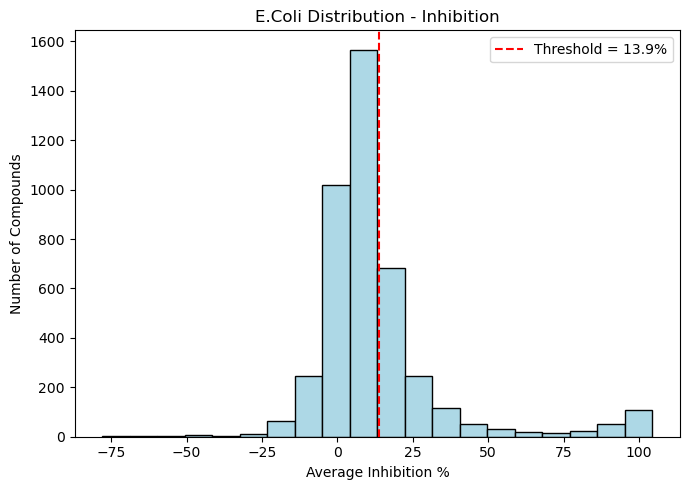

In [9]:
# Calculating the 70th percentile of INHIB_AVE to use as our cutoff
# Compounds above this value are active, below are inactive
threshold = master_df['INHIB_AVE'].quantile(0.7)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting the distribution of INHIB_AVE 
ax.hist(master_df['INHIB_AVE'], bins=20, edgecolor='black', color='lightblue')

# Adding a vertical line to show where the active/inactive cutoff is
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.1f}%')

# Adding the title and labels
ax.set_title('E.Coli Distribution - Inhibition')
ax.set_xlabel('Average Inhibition %')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

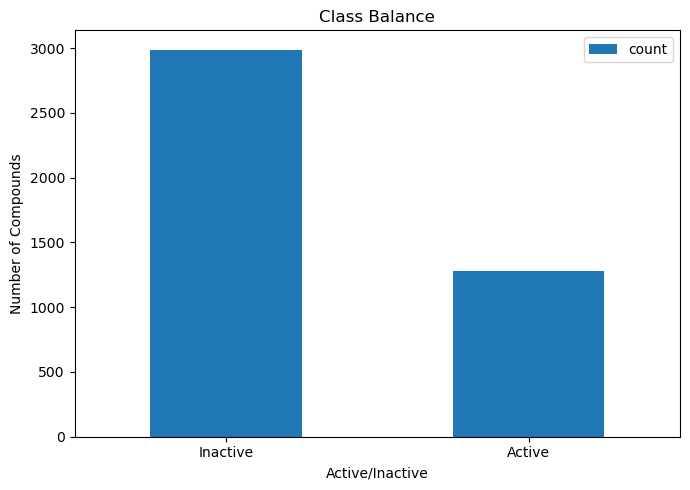

In [19]:
# Creating binary labels - 1 if compound is active (above threshold), 0 if inactive
ydummy_train = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting how many compounds fall into each class
ydummy_train.value_counts().plot(kind='bar', ax=ax)

# Labeling the bars and add title
ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.set_title('Class Balance')
ax.set_xlabel('Active/Inactive')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

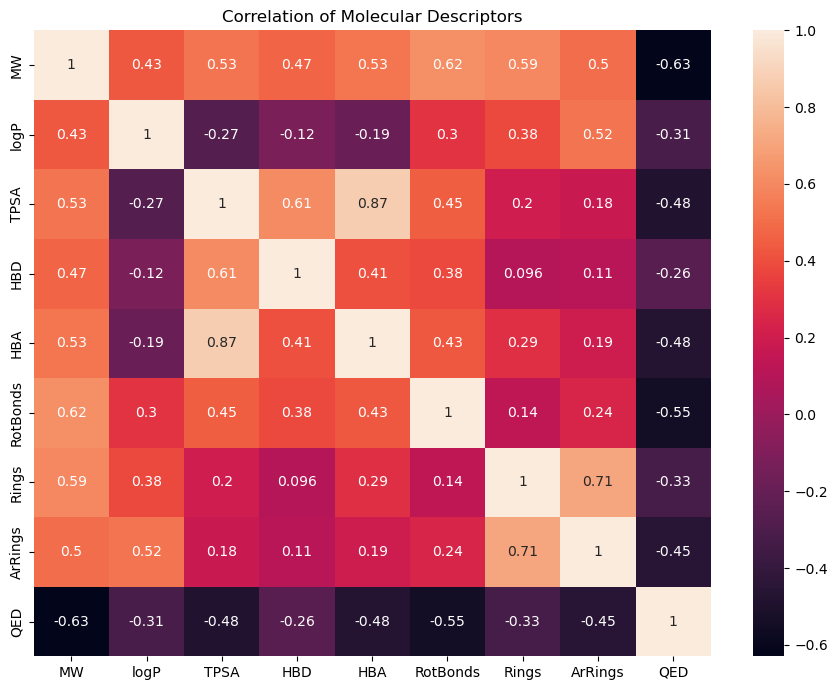

In [20]:
# Listing of the 9 molecular descriptors we computed from SMILES
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Making the figure
fig, ax = plt.subplots(figsize=(9,7))


# Plotting the correlation between all 9 descriptors
sns.heatmap(master_df[DESCRIPTOR_COLUMNS].corr(), annot=True, ax=ax)

# Adfding title
ax.set_title('Correlation of Molecular Descriptors')

plt.tight_layout()
plt.show()

---------------
## SVM (RBF) Motivation and Method

To capture potential nonlinear relationships between molecular descriptors and biological activity (INHIB_AVE), we applied a Support Vector Machine (SVM) with a radial basis function (RBF) kernel. Unlike linear models, the RBF kernel allows the decision boundary to bend in high-dimensional feature space, making it more suitable for complex structure–activity relationships where linear separability is not expected. This is particularly relevant for chemical descriptor data, where interactions between features (e.g., substructures and physicochemical properties) are often nonlinear.

We evaluated the model using two different binary classification thresholds based on the training distribution: the 70th percentile (moderate inhibition definition) and the 90th percentile (high-stringency, extreme inhibition definition). This allowed us to assess model robustness under different levels of class imbalance.

------------------
## Model Implementation

For each quantile setting, continuous INHIB_AVE values were converted into binary labels using a threshold computed from the training data. Samples above the threshold were labeled as high inhibition (1), and those below as low inhibition (0). The SVM model was then trained on scaled molecular descriptors using the RBF kernel with a fixed regularization parameter (C = 1.0) and automatic kernel width selection (gamma = "scale"). Class weighting was applied to partially correct for imbalance between classes.

After training, predictions were generated for both training and test sets. Model performance was evaluated using classification metrics including precision, recall, F1-score, and overall accuracy. This allowed assessment of both general predictive performance and sensitivity to the minority (high-inhibition) class.

In [8]:
def run_svm_rbf(X_train, X_test, y_train_cont, y_test_cont, quantile):

    threshold = y_train_cont.quantile(quantile)

    # create binary labels
    y_train_bin = (y_train_cont > threshold).astype(int)
    y_test_bin = (y_test_cont > threshold).astype(int)

    print(f"\nQuantile: {quantile}")
    print("Threshold:", threshold)
    print("Train class balance:")
    print(y_train_bin.value_counts())

    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )

    model.fit(X_train, y_train_bin)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\nTRAIN REPORT")
    print(classification_report(y_train_bin, y_pred_train))

    print("\nTEST REPORT")
    print(classification_report(y_test_bin, y_pred_test))

    print("Train accuracy:", accuracy_score(y_train_bin, y_pred_train))
    print("Test accuracy:", accuracy_score(y_test_bin, y_pred_test))

    return model, y_test_bin, y_pred_test

Now we run SVM RBF for 70% Quantile.


Quantile: 0.7
Threshold: 13.92
Train class balance:
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      2391
           1       0.84      0.94      0.88      1023

    accuracy                           0.93      3414
   macro avg       0.91      0.93      0.92      3414
weighted avg       0.93      0.93      0.93      3414


TEST REPORT
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       598
           1       0.57      0.54      0.56       256

    accuracy                           0.74       854
   macro avg       0.69      0.68      0.69       854
weighted avg       0.74      0.74      0.74       854

Train accuracy: 0.9270650263620387
Test accuracy: 0.7400468384074942


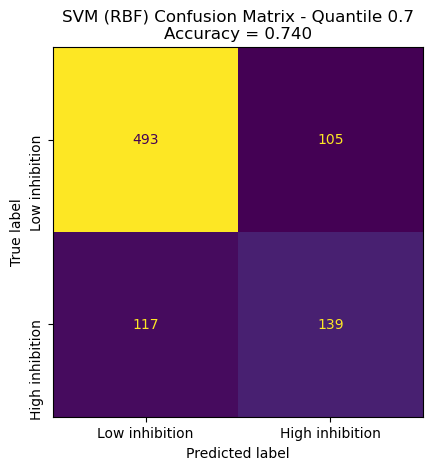

In [33]:
svm_70, y_test_bin_70, y_pred_test_70 = run_svm_rbf(X_train_scaled, X_test_scaled, y_train, y_test, 0.7)
cm = confusion_matrix(y_test_bin_70, y_pred_test_70)
acc = accuracy_score(y_test_bin_70, y_pred_test_70)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low inhibition", "High inhibition"])
disp.plot(colorbar=False)

plt.title(f"SVM (RBF) Confusion Matrix - Quantile 0.7\nAccuracy = {acc:.3f}")
plt.yticks(rotation=90)
plt.show()

The SVM with RBF kernel was trained using a 70th percentile threshold to define high inhibition, resulting in a more balanced class distribution compared to the 90th percentile case. On the training set, the model achieved strong performance (accuracy ~0.93), with particularly good recall for the high-inhibition class, indicating that the model can capture most active compounds during training. However, test performance dropped substantially (accuracy ~0.74), with a noticeable decline in precision and recall for the high-inhibition class (F1-score ~0.56). This gap between training and test performance suggests reduced generalization and potential overfitting to the training distribution. Overall, while the model is better at identifying high-inhibition compounds than linear approaches, performance remains limited on unseen data, particularly for the minority class.

Now we run SVM RBF for 90% Quantile.


Quantile: 0.9
Threshold: 30.94900000000002
Train class balance:
INHIB_AVE
0    3072
1     342
Name: count, dtype: int64

TRAIN REPORT
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      3072
           1       0.80      1.00      0.89       342

    accuracy                           0.97      3414
   macro avg       0.90      0.99      0.94      3414
weighted avg       0.98      0.97      0.98      3414


TEST REPORT
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       769
           1       0.59      0.49      0.54        85

    accuracy                           0.92       854
   macro avg       0.77      0.73      0.75       854
weighted avg       0.91      0.92      0.91       854

Train accuracy: 0.9745166959578208
Test accuracy: 0.9156908665105387


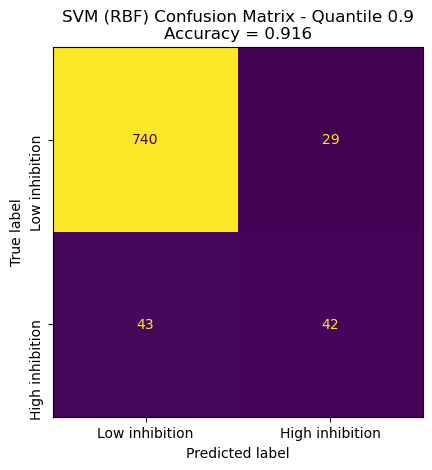

In [32]:
svm_90, y_test_bin_90, y_pred_test_90 = run_svm_rbf(X_train_scaled_90, X_test_scaled_90, y_train_90, y_test_90, 0.9)
cm_90 = confusion_matrix(y_test_bin_90, y_pred_test_90)
acc_90 = accuracy_score(y_test_bin_90, y_pred_test_90)

disp_90 = ConfusionMatrixDisplay(confusion_matrix=cm_90, display_labels=["Low inhibition", "High inhibition"])
disp_90.plot(colorbar=False)

plt.title(f"SVM (RBF) Confusion Matrix - Quantile 0.9\nAccuracy = {acc_90:.3f}")
plt.yticks(rotation=90)
plt.show()

The SVM with RBF kernel was trained using a high-inhibition definition based on the 90th percentile threshold, resulting in a strongly imbalanced dataset with only ~10% of samples classified as high inhibition. The model achieved high training performance (accuracy ~0.97), indicating strong capacity to fit the training data, particularly for the majority class. On the test set, performance remained strong overall (accuracy ~0.92), with high precision and recall for the low-inhibition class. However, performance on the high-inhibition class was noticeably weaker (F1-score ~0.57), reflecting the difficulty of correctly identifying rare high-activity compounds under class imbalance. Despite this, the model demonstrates that nonlinear decision boundaries (via the RBF kernel) can capture meaningful structure in the descriptor space better than linear approaches, though sensitivity to minority class prediction remains a limitation.

In [17]:
def tune_svm_rbf(X_train, X_test, y_train_cont, y_test_cont, quantile, c, g):

    threshold = y_train_cont.quantile(quantile)

    # create binary labels
    y_train_bin = (y_train_cont > threshold).astype(int)
    y_test_bin = (y_test_cont > threshold).astype(int)

    print(f"\nQuantile: {quantile}")
    print("Threshold:", threshold)
    print("Train class balance:")
    print(y_train_bin.value_counts())

    model = SVC(
        kernel="rbf",
        C=c,
        gamma=g,
        class_weight="balanced"
    )

    model.fit(X_train, y_train_bin)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("Train accuracy:", accuracy_score(y_train_bin, y_pred_train))
    print("Test accuracy:", accuracy_score(y_test_bin, y_pred_test))

    return model, y_test_bin, y_pred_test

### SVM RBF Hyperparameter Tuning

This section performs hyperparameter tuning for an SVM with an RBF kernel using stratified 5-fold cross-validation. It evaluates different combinations of C and gamma values to control model complexity and decision boundary flexibility. The performance metric used is recall, focusing on how well the model identifies the high-inhibition (positive) class. For each hyperparameter pair, recall is computed across all folds and summarized using the mean and standard deviation. The final output allows selection of the model that best maximizes sensitivity to positive compounds while maintaining stability across folds.

In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

c_tune = [0.01, 0.1, 1, 10, 100]
gamma_tune = [1e-4, 1e-3, 1e-2, 1e-1, 1]

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


y_train_bin_tune = y_binary_90.loc[X_train_90.index]

for C in c_tune:
    for gamma in gamma_tune:

        recall_scores = []

        for train_idx, val_idx in cv.split(X_train_scaled_90, y_train_bin_tune):

            X_tr = X_train_scaled_90.iloc[train_idx]
            X_val = X_train_scaled_90.iloc[val_idx]

            y_tr = y_train_bin_tune.iloc[train_idx]
            y_val = y_train_bin_tune.iloc[val_idx]

            model = SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                class_weight="balanced"
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)

            recall_scores.append(recall_score(y_val, y_pred))

        results.append({
            "C": C,
            "gamma": gamma,
            "recall_mean": np.mean(recall_scores),
            "recall_std": np.std(recall_scores)
        })

Now extract the best hyperparameters

In [26]:
best = max(results, key=lambda x: x["recall_mean"])

print("Best C:", best["C"])
print("Best gamma:", best["gamma"])
print("Best CV Recall:", best["recall_mean"], "+/-", best["recall_std"])

Best C: 1
Best gamma: 0.0001
Best CV Recall: 0.6489343563512361 +/- 0.05027713510893279


We then refit the model with the best hyperparmeters

In [27]:
best_model = SVC(
    kernel="rbf",
    C=best["C"],
    gamma=best["gamma"],
    class_weight="balanced"
)

best_model.fit(X_train_scaled_90, y_train_bin_tune)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.0001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


We evaluate the model performance

Best parameters (C, gamma): 1 0.0001
Test Accuracy: 0.8957845433255269

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       769
           1       0.48      0.68      0.57        85

    accuracy                           0.90       854
   macro avg       0.72      0.80      0.75       854
weighted avg       0.92      0.90      0.90       854



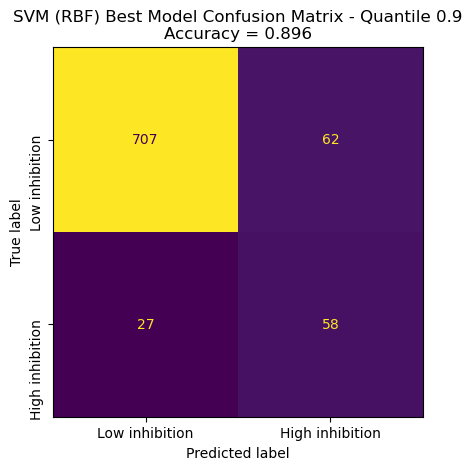

In [30]:
best_y_pred = best_model.predict(X_test_scaled_90)

# metrics
acc = accuracy_score(y_test_bin_90, best_y_pred)

print("Best parameters (C, gamma):", best["C"], best["gamma"])

print("Test Accuracy:", acc)

print("\nFINAL CLASSIFICATION REPORT")
print(classification_report(y_test_bin_90, best_y_pred))

# confusion matrix
cm = confusion_matrix(y_test_bin_90, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low inhibition", "High inhibition"])
disp.plot(colorbar=False)

plt.title(
    f"SVM (RBF) Best Model Confusion Matrix - Quantile 0.9\nAccuracy = {acc:.3f}"
)
plt.yticks(rotation=90)
plt.show()

The best SVM model with RBF kernel (C = 1, γ = 0.0001) achieved a test accuracy of approximately 0.90. However, due to class imbalance, accuracy alone is not fully representative of performance. The model performs very well on class 0 (low inhibition), with high precision (0.96) and recall (0.92), indicating strong ability to identify the majority class. For class 1 (high inhibition), performance is weaker, with precision of 0.48 but improved recall of 0.68, meaning the model captures most high-inhibition compounds but produces a moderate number of false positives. The macro-average recall of 0.80 suggests reasonable overall sensitivity across both classes. Overall, the model is better suited for screening applications where identifying potential high-inhibition candidates is more important than minimizing false positives.

### SVM RBF Discussion

Across the SVM RBF experiments, three configurations were evaluated: a 70th percentile threshold model, a 90th percentile threshold model, and a tuned 90th percentile model. The 70th percentile model achieved strong training performance (accuracy 0.93) but lower test performance (accuracy 0.74), with reduced performance on the minority class (high inhibition), where precision was 0.57 and recall was 0.54, indicating overfitting and limited generalization. The 90th percentile model improved overall test accuracy to 0.92, with strong majority class performance (precision 0.95, recall 0.96) but weaker high inhibition performance (precision 0.59, recall 0.49), reflecting persistent class imbalance effects. The tuned 90th percentile model achieved a test accuracy of about 0.90, with majority class performance remaining high (precision 0.96, recall 0.92) while high inhibition performance improved in recall to 0.68 but decreased in precision to 0.48. This indicates that tuning improved the model’s ability to identify more high inhibition compounds but also increased false positives. Across all models, the majority class consistently showed strong and stable performance, while the high inhibition class remained more difficult to classify reliably. The 90th percentile models performed better than the 70th percentile model in terms of overall test accuracy and generalization. However, improvements from hyperparameter tuning mainly shifted the precision–recall trade-off rather than resolving class overlap. These results suggest that threshold selection has a stronger impact on model behavior than tuning alone. Overall, the tuned 90th percentile SVM provides the best recall for high inhibition compounds (0.68), while the 90th percentile baseline offers the best balance between precision and stability.

------------------
## Simple Logistic Regression Model

In [13]:
threshold = y_train.quantile(0.7)

ydummy_train = (y_train > threshold).astype(int)
ydummy_test = (y_test > threshold).astype(int)

print("Threshold:", threshold)
print(ydummy_train.value_counts())

Threshold: 13.92
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64


0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

In [14]:
X_train_glm = sm.add_constant(X_train_scaled)

glm_model = sm.GLM(ydummy_train, X_train_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                         1037
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -801.42
Date:                Mon, 04 May 2026   Deviance:                       1602.8
Time:                        23:34:45   Pearson chi2:                 1.80e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5284
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.0054    252.243     -0.016   

We now make prediction on test dataset

Accuracy: 0.6791569086651054
               Feature      Coef  Odds Ratio
morgan_939  morgan_939  3.408989   30.234673
DMAX_AVE      DMAX_AVE  2.577169   13.159827
morgan_659  morgan_659  1.922687    6.839313
ArRings        ArRings  1.437385    4.209673
morgan_231  morgan_231  1.335015    3.800054
...                ...       ...         ...
morgan_561  morgan_561 -1.995253    0.135979
morgan_838  morgan_838 -2.235978    0.106888
morgan_312  morgan_312 -2.257393    0.104623
morgan_685  morgan_685 -2.305338    0.099725
morgan_373  morgan_373 -2.982933    0.050644

[1037 rows x 3 columns]


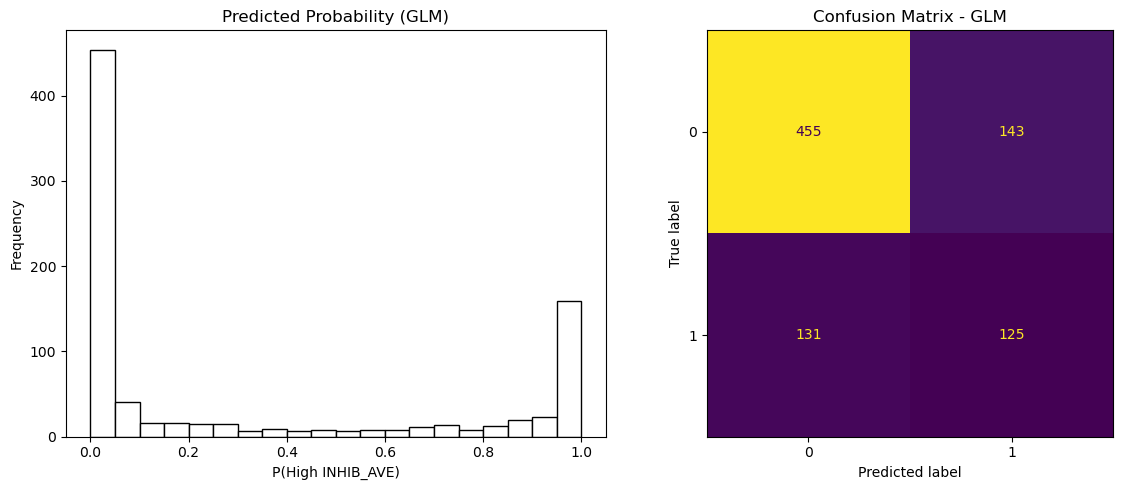

In [16]:
X_test_glm  = sm.add_constant(X_test_scaled, has_constant='add')

y_prob_log = glm_results.predict(X_test_glm)
y_pred_log = (y_prob_log > 0.5).astype(int)
print("Accuracy:", accuracy_score(ydummy_test, y_pred_log))

coefficients = pd.DataFrame({"Feature": X_train_scaled.columns, "Coef": glm_results.params[1:]})

coefficients["Odds Ratio"] = np.exp(coefficients["Coef"])

print(coefficients.sort_values("Odds Ratio", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Probability histogram
axes[0].hist(y_prob_log, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability (GLM)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")


# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report
print(classification_report(ydummy_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       598
           1       0.47      0.49      0.48       256

    accuracy                           0.68       854
   macro avg       0.62      0.62      0.62       854
weighted avg       0.68      0.68      0.68       854



The logistic regression (GLM with binomial family and logit link) achieved a test accuracy of 0.68 in classifying compounds as high or low inhibitory activity based on molecular descriptors and Morgan fingerprint features. Model performance was stronger for the low-activity class (precision 0.78, recall 0.76, F1-score 0.77) compared to the high-activity class (precision 0.47, recall 0.49, F1-score 0.48), indicating a bias toward correctly identifying inactive compounds. Feature analysis showed that several Morgan fingerprint bits and molecular descriptors had strong associations with activity, with positive predictors such as morgan_939, DMAX_AVE, and morgan_659 substantially increasing the odds of high activity, while other fingerprint bits showed strong negative associations. Overall, while the model captures meaningful structure–activity relationships, its moderate accuracy and weaker performance on the active class suggest limitations likely due to high-dimensional feature space and class imbalance effects.

-------------
## Logistic Regression with Feature Selection

Several predictors exhibited high p-values, suggesting redundancy and multicollinearity among molecular descriptors. While PCA could reduce dimensionality, it would compromise interpretability. Therefore, feature selection or more flexible nonlinear models may be more appropriate for capturing the structure–activity relationships present in the dataset.

In [18]:
# Copy coefficients from GLM results
coeffs = pd.DataFrame({
    "Feature": X_train_glm.columns,
    "Coef": glm_results.params
})

# Remove intercept
coeffs = coeffs[coeffs["Feature"] != "const"]

# Rank features by absolute coefficient magnitude
coeffs["abs_coef"] = coeffs["Coef"].abs()
top_features = coeffs.sort_values("abs_coef", ascending=False)

# Select top N features (e.g., 50)
selected_features = top_features["Feature"].head(50).tolist()

print("Selected features:", selected_features)

Selected features: ['morgan_939', 'morgan_373', 'DMAX_AVE', 'morgan_685', 'morgan_312', 'morgan_838', 'morgan_561', 'morgan_659', 'morgan_171', 'ArRings', 'morgan_87', 'HBA', 'morgan_231', 'morgan_112', 'morgan_693', 'logP', 'morgan_124', 'morgan_352', 'morgan_780', 'MIC_VALUE_uM', 'morgan_924', 'morgan_794', 'morgan_63', 'morgan_83', 'morgan_417', 'morgan_318', 'morgan_353', 'morgan_734', 'morgan_836', 'morgan_705', 'morgan_292', 'morgan_675', 'morgan_851', 'morgan_754', 'morgan_706', 'morgan_97', 'morgan_624', 'morgan_416', 'morgan_932', 'morgan_649', 'morgan_360', 'morgan_694', 'morgan_145', 'morgan_850', 'morgan_695', 'morgan_829', 'morgan_589', 'morgan_730', 'morgan_578', 'morgan_583']


In [23]:
# Reduce train/test sets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

# Add constant for GLM
X_train_fs_glm = sm.add_constant(X_train_fs, has_constant="add")
X_test_fs_glm = sm.add_constant(X_test_fs, has_constant="add")

# Refit GLM on selected features
glm_fs = sm.GLM(
    ydummy_train,
    X_train_fs_glm,
    family=sm.families.Binomial()
).fit()

# Predictions
y_prob_fs = glm_fs.predict(X_test_fs_glm)
y_pred_fs = (y_prob_fs > 0.5).astype(int)

print(glm_fs.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3363
Model Family:                Binomial   Df Model:                           50
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1653.0
Date:                Mon, 04 May 2026   Deviance:                       3306.1
Time:                        23:47:23   Pearson chi2:                 3.45e+03
No. Iterations:                    23   Pseudo R-squ. (CS):             0.2233
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.0793      0.285     -7.287   

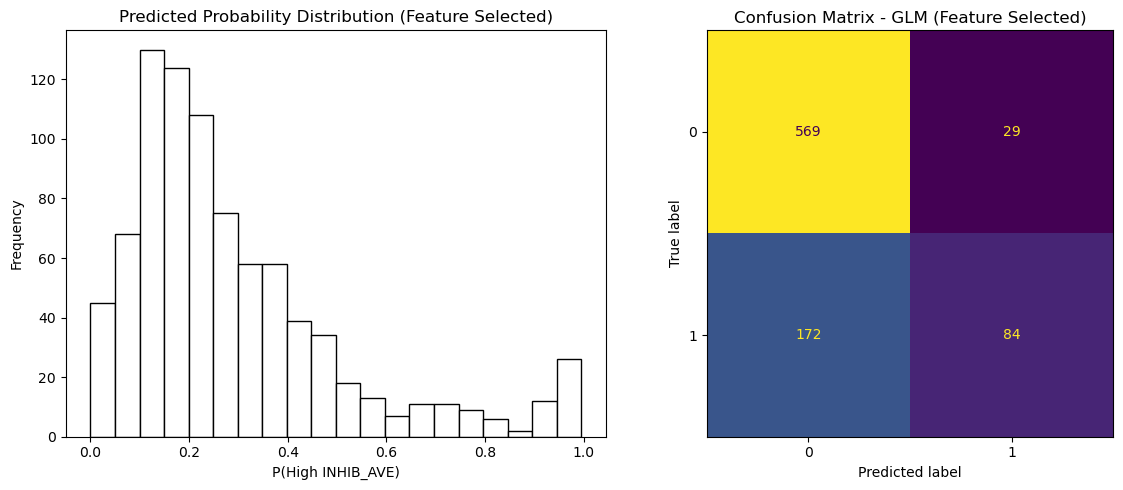

Accuracy (feature-selected model): 0.7646370023419203

Classification Report (Feature Selected GLM):

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       598
           1       0.74      0.33      0.46       256

    accuracy                           0.76       854
   macro avg       0.76      0.64      0.65       854
weighted avg       0.76      0.76      0.73       854



In [24]:
# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_fs)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - GLM (Feature Selected)")

# Probability distribution
axes[0].hist(y_prob_fs, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability Distribution (Feature Selected)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Evaluation
print("Accuracy (feature-selected model):", accuracy_score(ydummy_test, y_pred_fs))

# Classification report
print("\nClassification Report (Feature Selected GLM):\n")
print(classification_report(ydummy_test, y_pred_fs))

After applying feature selection based on the magnitude of logistic regression coefficients, a reduced GLM model was trained using only the most informative molecular descriptors and Morgan fingerprint features. This feature-selected model achieved a higher overall test accuracy of 0.76 compared to the full model, indicating improved general predictive performance. The model showed strong performance in identifying inactive compounds (class 0), with high recall (0.95) and solid precision (0.77), meaning it correctly captured most low-activity molecules. However, performance on active compounds (class 1) remained limited, with lower recall (0.33) despite moderate precision (0.74), indicating that many active compounds were still misclassified as inactive. Overall, feature selection improved model efficiency and overall accuracy while maintaining strong specificity for inactive compounds, but sensitivity to active compounds remains a key limitation.

-------------------------
## Logistic Regression with Feature Selection and Elastic Net Regularization

In [30]:
alphas = [0.001, 0.01, 0.1, 1]
l1_weights = [0.0, 0.25, 0.5, 0.75, 1.0]

best_score = 0
best_params = None
best_model = None

for alpha in alphas:
    for l1 in l1_weights:
        
        model = sm.GLM(
            ydummy_train,
            X_train_fs_glm,
            family=sm.families.Binomial()
        )
        
        result = model.fit_regularized(
            method="elastic_net",
            alpha=alpha,
            L1_wt=l1,
            maxiter=2000
        )
        
        y_prob = result.predict(X_test_fs_glm)
        y_pred = (y_prob > 0.3).astype(int)
        
        score = accuracy_score(ydummy_test, y_pred)
        
        if score > best_score:
            best_score = score
            best_params = (alpha, l1)
            best_model = result

print("Best accuracy:", best_score)
print("Best alpha, L1_wt:", best_params)

Best accuracy: 0.711943793911007
Best alpha, L1_wt: (0.001, 1.0)


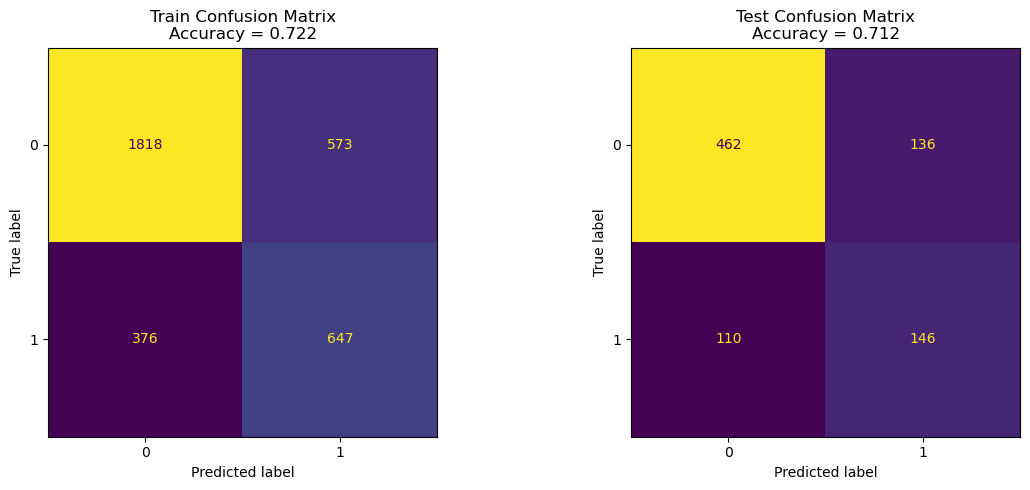

Train Accuracy: 0.7220269478617457
Test Accuracy: 0.711943793911007

Classification Report (Train):

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      2391
           1       0.53      0.63      0.58      1023

    accuracy                           0.72      3414
   macro avg       0.68      0.70      0.68      3414
weighted avg       0.74      0.72      0.73      3414


Classification Report (Test):

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       598
           1       0.52      0.57      0.54       256

    accuracy                           0.71       854
   macro avg       0.66      0.67      0.67       854
weighted avg       0.72      0.71      0.72       854



In [31]:
# Train predictions

y_prob_train = best_model.predict(X_train_fs_glm)
y_pred_train = (y_prob_train > 0.3).astype(int)

train_acc = accuracy_score(ydummy_train, y_pred_train)

cm_train = confusion_matrix(ydummy_train, y_pred_train)


# Test predictions

y_prob_test = best_model.predict(X_test_fs_glm)
y_pred_test = (y_prob_test > 0.3).astype(int)

test_acc = accuracy_score(ydummy_test, y_pred_test)

cm_test = confusion_matrix(ydummy_test, y_pred_test)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train CM
ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Train Confusion Matrix\nAccuracy = {train_acc:.3f}")

# Test CM
ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Test Confusion Matrix\nAccuracy = {test_acc:.3f}")

plt.tight_layout()
plt.show()

# Accuracies
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Full report 
print("\nClassification Report (Train):\n")
print(classification_report(ydummy_train, y_pred_train))

print("\nClassification Report (Test):\n")
print(classification_report(ydummy_test, y_pred_test))

The elastic net regularized logistic regression model was optimized using a grid search over different values of α (regularization strength) and L1 weighting, applied to a reduced feature set derived from molecular descriptors and Morgan fingerprints. In addition, the classification threshold was lowered from the default 0.5 to 0.3 to better address the class imbalance present in the dataset, where inactive compounds (class 0) were more prevalent than active compounds (class 1). This adjustment made the model more sensitive to predicting the minority class as active, reducing the bias toward the majority class. The best-performing model achieved a test accuracy of approximately 0.71. While overall accuracy decreased compared to higher threshold settings, performance for the active class improved notably, with recall increasing to 0.57 and F1-score reaching 0.54, indicating a better balance between identifying true actives and controlling false positives. However, this improvement came with a reduction in precision (0.52), reflecting an expected trade-off due to the lower decision threshold. Overall, adjusting the threshold to 0.3 helped mitigate the effects of class imbalance and improved the model’s ability to identify biologically relevant active compounds, even at the cost of increased false positive predictions.


------------
## Simple Linear Regression

This section performs a multiple linear regression analysis to model the relationship between molecular features and the continuous inhibition response variable, INHIB_AVE. The scaled training features are combined with the target values into a single dataframe, and an ordinary least squares (OLS) regression model is fit using all available predictors. The resulting model summary provides statistical information about feature significance, model fit, and overall regression performance.

In [32]:
# build training dataframe
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# fit model
lin_model = ols(equation, data=lin_df).fit()

# summary
print(lin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     6.046
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.18e-286
Time:                        00:10:22   Log-Likelihood:                -13159.
No. Observations:                3414   AIC:                         2.839e+04
Df Residuals:                    2376   BIC:                         3.476e+04
Df Model:                        1037                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.8793      0.234     54.961   

Now we use the linear regression model to predict our test set and evaluate the model using R squared (R2), mean squared error (MSE), mean abosoulte error (MAE), and root mean squared error (RMSE).

In [33]:
# build test dataframe
lin_test_df = X_test_scaled.copy()

# predict
y_pred_lin = lin_model.predict(lin_test_df)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.4044188819346942
MSE: 289.30908644824717
MAE: 12.48844915130756
RMSE: 17.009088348534355


The linear regression model achieved an R² value of approximately 0.40, indicating that the model explains about 40% of the variance in the inhibition data. While this suggests some predictive relationship between the molecular features and INHIB_AVE, a substantial portion of the variability remains unexplained, implying that the relationship is likely nonlinear or more complex. The model produced a mean absolute error (MAE) of approximately 12.49 and a root mean squared error (RMSE) of 17.01, indicating moderate prediction error magnitude. Overall, these results suggest that simple linear regression provides a limited baseline performance and that more flexible nonlinear models may better capture the underlying structure of the data.

Now we evaluate the performance of the linear regression model by comparing predicted inhibition values against the true test values. A predicted-versus-actual scatter plot is generated, along with a reference diagonal line representing perfect predictions. The spread of points around the diagonal provides a visual indication of model accuracy and prediction error. In addition, the mean absolute deviation (MAD) is calculated to quantify the average magnitude of prediction errors between the observed and predicted INHIB_AVE values.

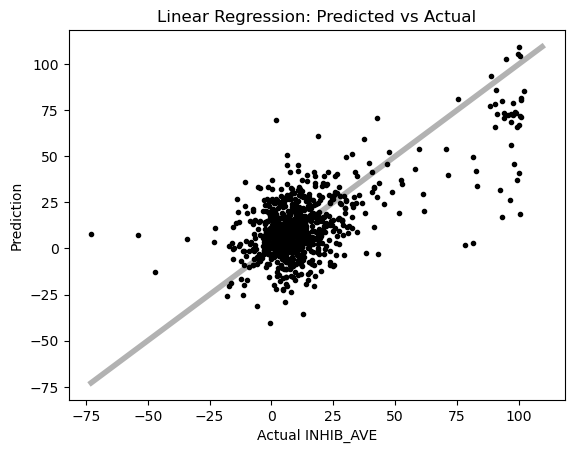

Mean Absolute Deviation: 12.48844915130756


In [34]:
higher = max(y_pred_lin.max(), y_test.max())
lower = min(y_pred_lin.min(), y_test.min())
plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

# scatter plot
plt.scatter(y_test, y_pred_lin, marker='.', color='black')

plt.ylabel('Prediction')
plt.xlabel('Actual INHIB_AVE')
plt.title('Linear Regression: Predicted vs Actual')

plt.show()

# mean absolute deviation
mean_dev = np.mean(np.abs(y_test - y_pred_lin))
print("Mean Absolute Deviation:", mean_dev)

The linear regression plot shows a large concentration of samples with actual INHIB_AVE values between approximately 0 and 25, forming a dense central cluster rather than a clear linear trend along the diagonal reference line. While some predictions fall near the ideal regression line, many points are scattered far from it, indicating substantial prediction error and weak agreement between predicted and actual values. In addition, relatively few samples are present at higher inhibition values, suggesting an uneven target distribution that may further limit model performance. The mean absolute deviation (MAD) of 12.488 indicates that predicted inhibition values differ from the true values by a moderate amount on average, reinforcing that simple linear regression may not adequately capture the complexity of the dataset.

------------------

## Simple Linear Regression with Feature Selection

This section applies feature selection to the linear regression model using statistical significance testing from an initial OLS fit. Features with p-values below 0.05 are retained, indicating a statistically meaningful relationship with INHIB_AVE, while non-significant predictors are removed to reduce model complexity. The dataset is then reduced to only these selected features, and a new OLS regression model is trained using this subset. This approach aims to improve interpretability and potentially enhance model stability by focusing only on the most informative molecular descriptors.

In [8]:
# Build dataset
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# Full model formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# Fit full OLS model
lin_model = ols(equation, data=lin_df).fit()

# Extract p-values (excluding intercept)
pvalues = lin_model.pvalues.drop("Intercept")

# Select significant features (p < 0.05)
selected_features = pvalues[pvalues < 0.05].index.tolist()

print("Selected features (p < 0.05):")
print(selected_features)

Selected features (p < 0.05):
['DMAX_AVE', 'HBA', 'morgan_8', 'morgan_11', 'morgan_21', 'morgan_36', 'morgan_67', 'morgan_69', 'morgan_75', 'morgan_82', 'morgan_92', 'morgan_129', 'morgan_150', 'morgan_154', 'morgan_156', 'morgan_159', 'morgan_182', 'morgan_185', 'morgan_188', 'morgan_200', 'morgan_208', 'morgan_212', 'morgan_227', 'morgan_232', 'morgan_233', 'morgan_237', 'morgan_248', 'morgan_259', 'morgan_276', 'morgan_304', 'morgan_309', 'morgan_331', 'morgan_344', 'morgan_353', 'morgan_371', 'morgan_373', 'morgan_376', 'morgan_384', 'morgan_392', 'morgan_407', 'morgan_416', 'morgan_417', 'morgan_421', 'morgan_432', 'morgan_455', 'morgan_456', 'morgan_464', 'morgan_465', 'morgan_499', 'morgan_500', 'morgan_504', 'morgan_505', 'morgan_516', 'morgan_517', 'morgan_525', 'morgan_547', 'morgan_557', 'morgan_567', 'morgan_589', 'morgan_590', 'morgan_607', 'morgan_608', 'morgan_617', 'morgan_621', 'morgan_624', 'morgan_633', 'morgan_651', 'morgan_659', 'morgan_666', 'morgan_675', 'morgan_

Now we fit the model

In [37]:
# Reduce dataset to selected features
X_train_fs = X_train_scaled[selected_features]
X_test_fs = X_test_scaled[selected_features]

# Add target
lin_df_fs = X_train_fs.copy()
lin_df_fs["INHIB_AVE"] = y_train

# Build new formula
equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)

# Fit reduced model
lin_model_fs = ols(equation_fs, data=lin_df_fs).fit()

print(lin_model_fs.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     48.05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        00:14:54   Log-Likelihood:                -13855.
No. Observations:                3414   AIC:                         2.791e+04
Df Residuals:                    3315   BIC:                         2.852e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      12.8793      0.243     52.945      

Now we use the linear regression model to evaluate training fit and predict our test set. The evaluation metrics for the model performance are R squared (R2), mean squared error (MSE), mean abosoulte error (MAE), and root mean squared error (RMSE).

In [41]:
# prediction
y_pred_train = lin_model_fs.predict(X_train_fs)
y_pred_test = lin_model_fs.predict(X_test_fs)

# evaluation
print("TRAIN METRICS:")
print("R2:", r2_score(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))

print("\nTEST METRICS:")
print("R2:", r2_score(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

TRAIN METRICS:
R2: 0.5868424543413483
MSE: 196.16528533196265
MAE: 10.064522589067273
RMSE: 14.005901803595606

TEST METRICS:
R2: 0.5360280598880529
MSE: 225.3786999954719
MAE: 10.41946576187494
RMSE: 15.0126180260297


The feature-selected linear regression model shows improved performance compared to the full model, with a test R² of approximately 0.54, indicating a moderate ability to explain variance in `INHIB_AVE`. The reduction in MSE, MAE, and RMSE suggests that removing statistically insignificant features helped improve both accuracy and generalization. The close alignment between training and test metrics also indicates reduced overfitting and better model stability. However, the remaining error levels still suggest that linear relationships alone are insufficient to fully capture the complexity of the inhibition data.


Next, we visualize the performance of the feature-selected linear regression model by plotting predicted versus actual INHIB_AVE values against a reference diagonal line representing perfect predictions, and quantifies the average prediction error using the mean absolute deviation.

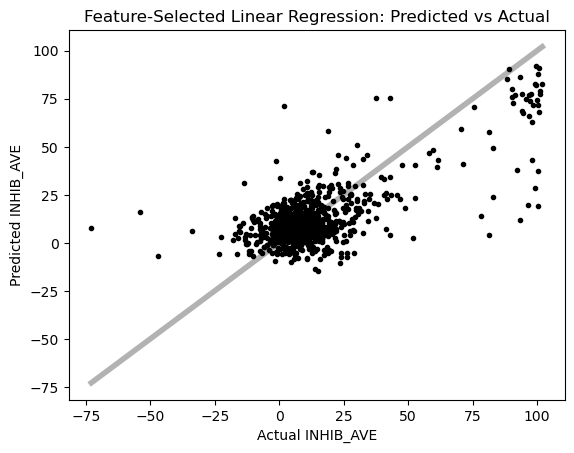

Mean Absolute Deviation: 10.41946576187494


In [42]:
higher = max(y_pred_test.max(), y_test.max())
lower = min(y_pred_test.min(), y_test.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test, y_pred_test, marker='.', color='black')

plt.ylabel('Predicted INHIB_AVE')
plt.xlabel('Actual INHIB_AVE')
plt.title('Feature-Selected Linear Regression: Predicted vs Actual')

plt.show()


# Mean Absolute Deviation

mean_dev = np.mean(np.abs(y_test - y_pred_test))
print("Mean Absolute Deviation:", mean_dev)

Compared to the full linear regression model without feature selection, the feature-selected model shows a slightly tighter clustering of points around the diagonal reference line, indicating improved alignment between predicted and actual INHIB_AVE values. However, there remains noticeable dispersion, particularly in the range of approximately -10 to 30, where many samples deviate from the ideal prediction line, as well as for higher inhibition compounds where prediction errors are more pronounced. This suggests that while feature selection improves model focus and reduces noise, the linear model still struggles to fully capture variability in the dataset. The mean absolute deviation of 10.42 reflects a moderate average prediction error, consistent with these observed deviations.

------------------
# Selected X_Train Window for Simple Linear Regression

This section refines the feature-selected linear regression model by restricting both the training and testing data to a defined inhibition range of -20 to 30, focusing the analysis on the central region of the response distribution. The model is then retrained using only the previously selected significant features within this filtered dataset. This approach reduces the influence of extreme values and aims to improve model stability within the most data-dense region. The resulting OLS summary provides updated statistical insights into feature significance and model performance under this constrained range.

We prepare masked x_train and x_test in the inhibition range of -20 to 30 as well as using feature selection. Then, a simple linear regression is fitted using masked x_train.

In [9]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].reset_index(drop=True).copy()
y_train_f = y_train.loc[mask_train].reset_index(drop=True).copy()

X_test_f = X_test_scaled.loc[mask_test].reset_index(drop=True).copy()
y_test_f = y_test.loc[mask_test].reset_index(drop=True).copy()

X_train_fs_m = X_train_f[selected_features]
X_test_fs_m = X_test_f[selected_features]

train_fs_df = X_train_fs_m.copy()
train_fs_df["INHIB_AVE"] = y_train_f

equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)
ols_fs_m = ols(equation_fs, data=train_fs_df).fit()

print(ols_fs_m.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     4.924
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.38e-47
Time:                        23:46:28   Log-Likelihood:                -10728.
No. Observations:                3030   AIC:                         2.165e+04
Df Residuals:                    2931   BIC:                         2.225e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.0551      0.170     47.374      

Now, we evaluate the performance of the feature-selected linear regression model on a restricted inhibition range by generating predictions on the filtered test set and computing key regression metrics including R², RMSE, and MAE. A predicted-versus-actual scatter plot is used to visually assess model fit against the ideal diagonal reference line. This allows for a focused evaluation of model performance within the most data-dense region of the target distribution.


TEST METRICS
R2: 0.05245545022954512
RMSE: 8.609243972331377
MAE: 6.709461255483722


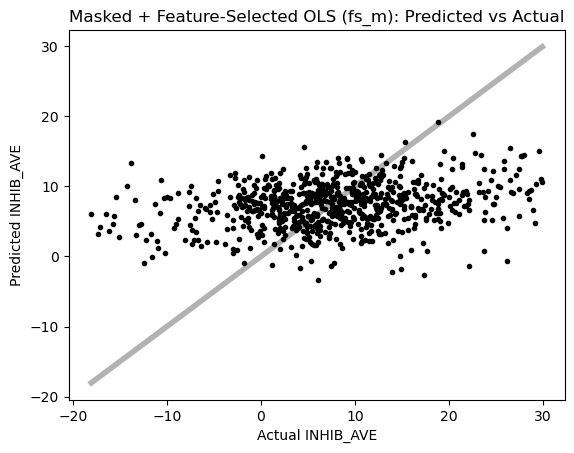

In [10]:
y_pred_test = ols_fs_m.predict(X_test_fs_m)

r2 = r2_score(y_test_f, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test_f, y_pred_test))
mae = mean_absolute_error(y_test_f, y_pred_test)

print("\nTEST METRICS")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

higher = max(y_pred_test.max(), y_test_f.max())
lower = min(y_pred_test.min(), y_test_f.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test_f, y_pred_test, marker='.', color='black')

plt.xlabel("Actual INHIB_AVE")
plt.ylabel("Predicted INHIB_AVE")
plt.title("Masked + Feature-Selected OLS (fs_m): Predicted vs Actual")

plt.show()

The masked and feature-selected linear regression model shows a substantial drop in performance on the restricted -20 to 30 range, with an R² of approximately 0.05, indicating very limited explanatory power. The scatter plot reflects this, with predictions widely dispersed and only a small concentration of points near the diagonal reference line, suggesting weak alignment between predicted and actual values. This increased spread indicates that restricting the dataset reduced structural patterns that the model was previously capturing. Despite this, the RMSE (8.61) and MAE (6.71) suggest moderate average prediction error, though overall predictive reliability in this constrained region is weak.


--------------------
## Error Weighted and Selected X_Train Window for Simple Linear Regression

This section applies a Weighted Least Squares (WLS) regression model to account for heteroscedasticity in the inhibition data by assigning higher weights to observations with lower experimental variability (INHIB_STD). The dataset is first restricted to the -20 to 30 inhibition range, and selected noisy or less informative features (INHIB_STD, NASSAYS) are removed prior to modeling. Weights are defined as an inverse function of INHIB_STD, controlled by hyperparameters α (alpha) and ε (epsilon) to adjust sensitivity and numerical stability. The model is then fit across multiple combinations of these parameters, and performance is evaluated using R² and RMSE on the test set. A combined scoring function balancing goodness-of-fit and prediction error is used to rank models and identify the optimal weighting configuration. This approach aims to improve regression robustness by explicitly accounting for variability in measurement uncertainty across samples.

Weighted Least Squares (WLS) regression was implemented using the statsmodels WLS function to account for heteroscedasticity in the error structure. In this framework, observations are assigned weights inversely proportional to their variance, giving less influence to high-variance samples and more influence to more reliable measurements (Kutner et al., 2005, *Applied Linear Statistical Models*, Chapter 11).

Preparation for masked x_train, x_test, y_train, and y_test

In [43]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].copy()
y_train_f = y_train.loc[mask_train].copy()

X_test_f = X_test_scaled.loc[mask_test].copy()
y_test_f = y_test.loc[mask_test].copy()

In [44]:
# remove INHIB_STD and NASSAYSfrom feature
X_train_w = X_train_f.drop(columns=["INHIB_STD", "NASSAYS"])
X_test_w  = X_test_f.drop(columns=["INHIB_STD", "NASSAYS"])

Fitting WLS

In [45]:
# Fit WLS

alphas = [0.5, 1.0, 1.5, 2.0]
epsilons = [1e-3, 1e-2, 1e-1, 1]

results = []

X_train_w_const = sm.add_constant(X_train_w)
X_test_w_const = sm.add_constant(X_test_w)

for alpha in alphas:
    for eps in epsilons:
       # error weighing
       w = 1 / ((X_train_f["INHIB_STD"] + eps) ** alpha)

       # stabilize
       w = np.nan_to_num(w, nan=1.0, posinf=50, neginf=1.0)
       w = np.clip(w, 0, 50)
       w = w / np.mean(w)

       weights = w

       model = sm.WLS(y_train_f, X_train_w_const, weights=weights).fit()

       y_pred = model.predict(X_test_w_const)

       r2 = r2_score(y_test_f, y_pred)
       rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))

       results.append((alpha, eps, r2, rmse))

scored_results = []

for r in results:
    alpha, eps, r2, rmse = r

    score = r2 - 0.01 * rmse  # balance fit + error

    scored_results.append((alpha, eps, r2, rmse, score))

scored_results = sorted(scored_results, key=lambda x: x[4], reverse=True)

for r in scored_results[:5]:
    print("alpha:", r[0],
          "eps:", r[1],
          "R2:", r[2],
          "RMSE:", r[3],
          "Score:", r[4])

alpha: 1.0 eps: 0.001 R2: -267.09778805598694 RMSE: 144.81442082511776 Score: -268.5459322642381
alpha: 1.0 eps: 0.01 R2: -340.3747888067309 RMSE: 163.41086108312547 Score: -342.0088974175622
alpha: 1.5 eps: 0.001 R2: -428.18682739386594 RMSE: 183.22654326332753 Score: -430.0190928264992
alpha: 1.5 eps: 0.1 R2: -430.77338374509435 RMSE: 183.77783450415902 Score: -432.61116209013596
alpha: 1.0 eps: 0.1 R2: -432.0037245323545 RMSE: 184.03948625040445 Score: -433.8441193948586


The linear regression model performed poorly, with a strongly negative R² and high RMSE, indicating that it fails to capture meaningful structure–activity relationships in the dataset. This is likely due to the high-dimensional, sparse nature of Morgan fingerprint features and multicollinearity among predictors, which violate the assumptions of ordinary least squares regression.

### Linear Regression Discussion

Across the linear regression experiments, several progressively refined approaches were used to model the relationship between molecular descriptors and INHIB_AVE. The initial simple linear regression provided a baseline performance with an R2 of 0.40 and relatively high error (RMSE about 17.01, MAE about 12.49), indicating that the model captures some structure in the data but leaves a large portion of variability unexplained. Visual inspection showed a dense central cluster of predictions with noticeable scatter away from the diagonal line, particularly in the mid-range (approximately -10 to 30), suggesting limited linear structure and substantial noise. Feature selection using p-value filtering improved performance, increasing test R2 to 0.54 and reducing error (RMSE about 15.01, MAE about 10.42), while also improving alignment between training and test results, suggesting reduced overfitting. Despite this improvement, predictions still showed considerable dispersion around the diagonal, especially for higher inhibition values, indicating that important nonlinear relationships were not captured. Restricting the dataset to the -20 to 30 range further changed model behavior but led to a sharp drop in performance, with R2 decreasing to 0.05 and MAE increasing to 6.71, suggesting that removing extreme values also removed informative variation needed to capture broader trends. Weighted Least Squares (WLS) regression was then applied to address heteroscedasticity by assigning weights inversely proportional to observation variance, aiming to reduce the influence of noisy measurements. However, all tested WLS configurations produced strongly negative R2 values and large RMSE, indicating that the weighting scheme based on INHIB_STD does not align with the true error structure of the data. Instead of stabilizing the regression fit, the applied weights appear to amplify sensitivity to noisy observations, leading to unstable parameter estimates. Overall, the consistently poor performance across linear regression variants further supports the conclusion that the relationship between molecular descriptors and INHIB_AVE is likely nonlinear and cannot be adequately captured using linear models alone.


---------------
## Clustering Visualization (90% Quantile)

This section visualizes the high-dimensional molecular feature space using UMAP dimensionality reduction to project the data into a 2D representation. The target variable INHIB_AVE is binarized using the 90th percentile threshold to distinguish between low and high inhibition compounds. The resulting plot shows the spatial distribution of both classes in the reduced feature space, allowing assessment of whether the two groups form separable clusters. This visualization helps evaluate the inherent structure of the data and whether high-inhibition compounds exhibit distinct patterns from the rest of the dataset.

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


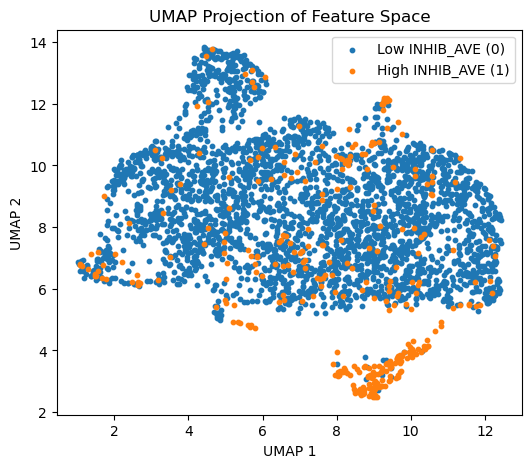

In [ ]:
threshold = y_train.quantile(0.9)
y_umap = (y_train > threshold).astype(int)

umap_data = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42).fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))

# class 0
plt.scatter(
    umap_data[y_umap == 0, 0],
    umap_data[y_umap == 0, 1],
    s=10,
    label="Low INHIB_AVE (0)"
)

# class 1
plt.scatter(
    umap_data[y_umap == 1, 0],
    umap_data[y_umap == 1, 1],
    s=10,
    label="High INHIB_AVE (1)"
)

plt.title("UMAP Projection of Feature Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend()
plt.show()

The UMAP projection shows that low inhibition compounds form a large, diffuse cluster covering most of the feature space, while high inhibition compounds are mostly concentrated in a smaller region toward the bottom-right. However, a small number of high inhibition samples are also embedded within the larger low inhibition cluster, indicating some overlap between the two groups. This suggests that while there is partial separability, the classes are not fully distinct in the projected feature space.

Next, we apply UMAP visualization to a filtered subset of the data restricted to the -20 to 30 INHIB_AVE range, focusing on the central region of the distribution. The samples are then split into low and high groups based on the median value to provide a relative comparison within this constrained range. The resulting plot shows how the feature space structure changes under this restriction and whether local separability between the two groups is preserved.

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


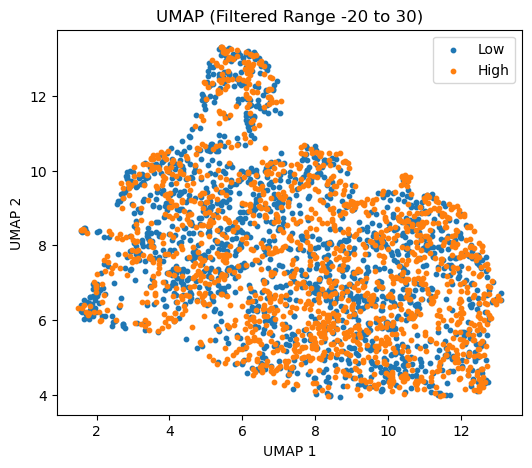

In [ ]:
mask = (y_train >= -20) & (y_train <= 30)

X_umap = X_train_scaled.loc[mask].copy()
y_umap = y_train.loc[mask].copy()

umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_umap)

labels = (y_umap > y_umap.median()).astype(int)

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="Low"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="High"
)

plt.title("UMAP (Filtered Range -20 to 30)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

The UMAP projection of the filtered -20 to 30 range shows that the low and high inhibition groups are almost completely overlapping in the feature space. There is no clear separation between the two classes, with both labels distributed across the same regions of the embedding. This suggests that within this restricted range, the molecular descriptors do not contain strong enough structure to distinguish between higher and lower inhibition values.

---------

## K-Means Clustering with PCA

This section applies PCA to reduce the feature space to two dimensions and then performs K-Means clustering on the transformed data. Two different binary label definitions are used based on the 70th and 90th percentile thresholds of INHIB_AVE, allowing comparison of clustering behavior under different class imbalances. The resulting plots compare the true label distributions against the unsupervised K-Means cluster assignments in PCA space. This visualization helps assess how well unsupervised clustering aligns with the underlying inhibition-based groupings.

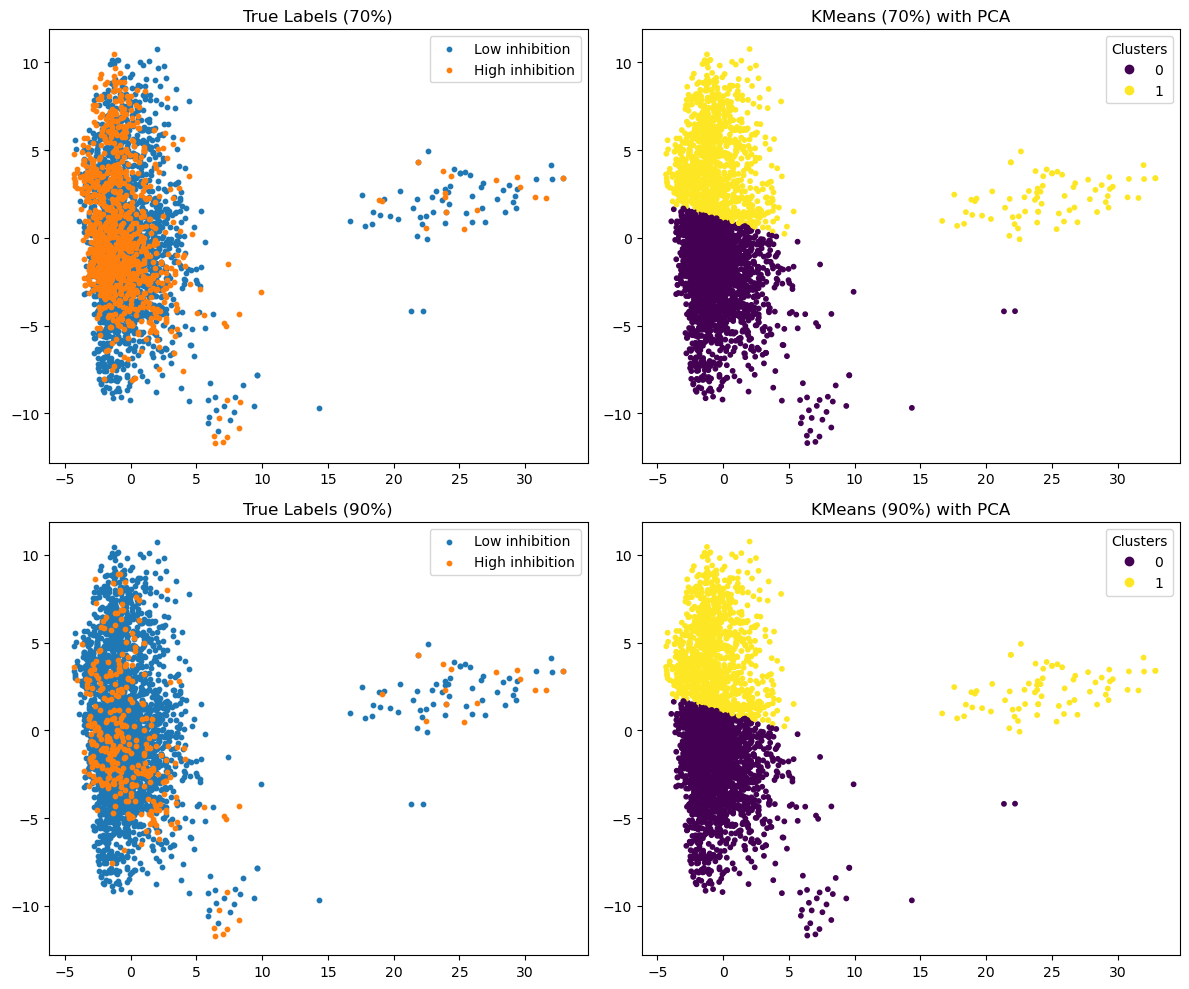

In [17]:
# PCA
X_np = X_train_scaled.to_numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

dist = distance_metric(type_metric.EUCLIDEAN)

# ---------------------------
# 70% quantile
# ---------------------------
threshold_70 = y_train.quantile(0.7)
y_train_class_70 = (y_train > threshold_70).astype(int)

km_model_70 = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels_70 = km_model_70.cluster(X_pca, assign_clusters=True)

# ---------------------------
# 90% quantile
# ---------------------------
threshold_90 = y_train.quantile(0.9)
y_train_class_90 = (y_train > threshold_90).astype(int)

km_model_90 = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels_90 = km_model_90.cluster(X_pca, assign_clusters=True)

# ---------------------------
# PLOTS (2x2)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# --- True 70% ---
axes[0,0].scatter(
    X_pca[y_train_class_70 == 0, 0],
    X_pca[y_train_class_70 == 0, 1],
    s=10, label="Low inhibition"
)
axes[0,0].scatter(
    X_pca[y_train_class_70 == 1, 0],
    X_pca[y_train_class_70 == 1, 1],
    s=10, label="High inhibition"
)
axes[0,0].set_title("True Labels (70%)")
axes[0,0].legend()

# --- KMeans 70% ---
scatter1 = axes[0,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels_70,
    cmap='viridis',
    s=10
)
axes[0,1].set_title("KMeans (70%) with PCA")
axes[0,1].legend(*scatter1.legend_elements(), title="Clusters")

# --- True 90% ---
axes[1,0].scatter(
    X_pca[y_train_class_90 == 0, 0],
    X_pca[y_train_class_90 == 0, 1],
    s=10, label="Low inhibition"
)
axes[1,0].scatter(
    X_pca[y_train_class_90 == 1, 0],
    X_pca[y_train_class_90 == 1, 1],
    s=10, label="High inhibition"
)
axes[1,0].set_title("True Labels (90%)")
axes[1,0].legend()

# --- KMeans 90% ---
scatter2 = axes[1,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels_90,
    cmap='viridis',
    s=10
)
axes[1,1].set_title("KMeans (90%) with PCA")
axes[1,1].legend(*scatter2.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

The PCA-based visualization indicates that the feature space contains a degree of intrinsic structure, with compounds forming partially organized groupings in the reduced-dimensional representation. However, when these projections are colored by the INHIB_AVE-derived labels, there is no clear separation between high and low inhibition classes. This suggests that while the molecular descriptor space captures meaningful variance and underlying structure in the data, this structure does not directly correspond to the target variable. As a result, the relationship between the input features and INHIB_AVE appears to be weakly aligned with linear or low-dimensional separability, limiting the effectiveness of unsupervised projections for distinguishing inhibition levels.

 ## GMM–UMAP plot

To further investigate whether the bimodal structure identified in the target variable (INHIB_AVE) is reflected in the feature space, a Gaussian Mixture Model (GMM) was fitted to INHIB_AVE to identify potential latent subpopulations. The resulting cluster assignments were then projected onto a UMAP embedding of the scaled feature set. This allows us to assess whether the distribution-based clusters correspond to any separable structure in the high-dimensional feature space.

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


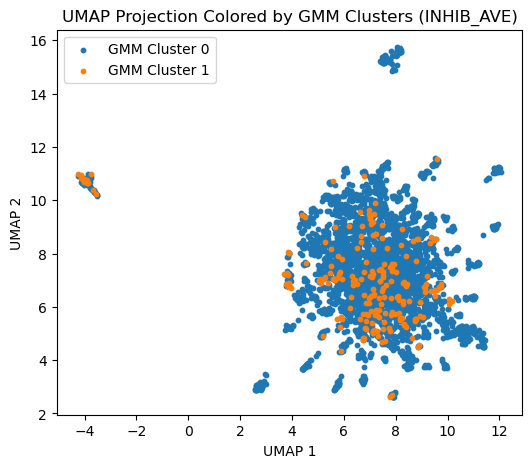

In [51]:
# UMAP on feature space
umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_train_scaled)

# GMM labels (from y_train)
labels = gmm.predict(y_train.values.reshape(-1, 1))

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="GMM Cluster 0"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="GMM Cluster 1"
)

plt.title("UMAP Projection Colored by GMM Clusters (INHIB_AVE)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

The resulting projection shows that the two GMM clusters are not well separated in the reduced space. In particular, high inhibition samples are largely embedded within regions dominated by low inhibition samples, with substantial overlap between the two groups. This suggests that the probabilistic clustering structure identified by GMM does not align cleanly with distinct separable regions in the feature space.

---------------
## GMM with PCA

This section applies Gaussian Mixture Model (GMM) clustering to PCA-reduced feature space and compares the resulting clusters against true inhibition-based labels defined using both the 70th and 90th percentile thresholds. The visualization shows that while GMM identifies distinct probabilistic clusters in the data, these clusters do not align cleanly with the high and low inhibition groupings. In both the 70% and 90% cases, there is substantial overlap between true labels and GMM-assigned clusters in the PCA space. High inhibition samples are distributed across regions dominated by low inhibition samples, indicating weak separability in the feature representation. This suggests that although GMM captures some underlying structure, it does not recover clear biologically meaningful groupings based on INHIB_AVE. Overall, the clustering results reinforce the difficulty of separating inhibition levels using linear or Gaussian-based assumptions in the current feature space.

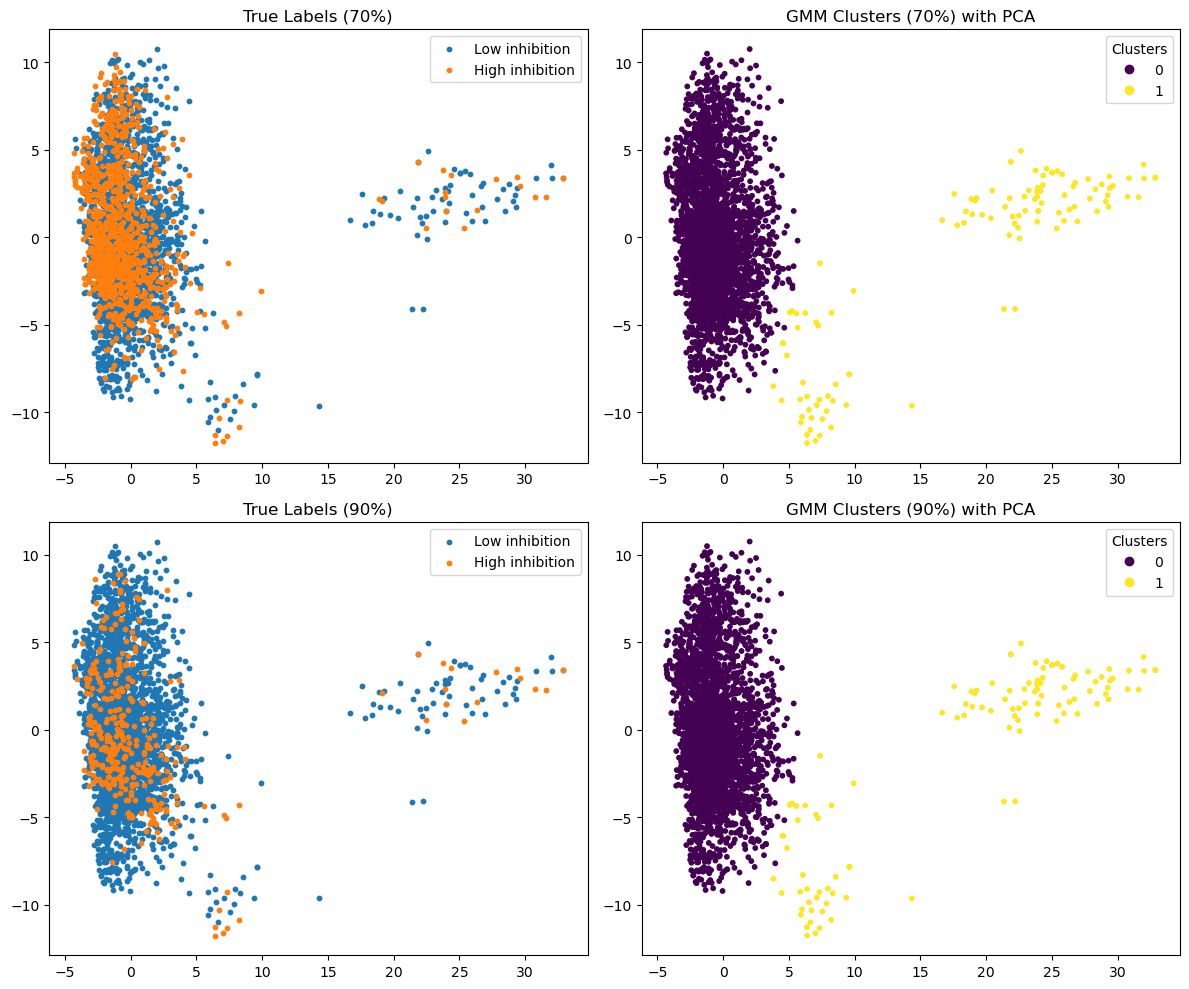

In [18]:
# PCA
pca_gmm = PCA(n_components=2)
X_pca = pca_gmm.fit_transform(X_train_scaled)

# -----------------------
# 70% quantile labels
# -----------------------
threshold_70 = y_train.quantile(0.7)
y_train_class_70 = (y_train > threshold_70).astype(int)

# GMM (70%)
gmm_70 = GaussianMixture(n_components=2, random_state=42)
gmm_labels_70 = gmm_70.fit_predict(X_pca)

# -----------------------
# 90% quantile labels
# -----------------------
threshold_90 = y_train.quantile(0.9)
y_train_class_90 = (y_train > threshold_90).astype(int)

# GMM (90%)
gmm_90 = GaussianMixture(n_components=2, random_state=42)
gmm_labels_90 = gmm_90.fit_predict(X_pca)

# -----------------------
# PLOTS (2x2)
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# --- True 70% ---
axes[0,0].scatter(
    X_pca[y_train_class_70 == 0, 0],
    X_pca[y_train_class_70 == 0, 1],
    s=10, label="Low inhibition"
)
axes[0,0].scatter(
    X_pca[y_train_class_70 == 1, 0],
    X_pca[y_train_class_70 == 1, 1],
    s=10, label="High inhibition"
)
axes[0,0].set_title("True Labels (70%)")
axes[0,0].legend()

# --- GMM 70% ---
scatter1 = axes[0,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels_70,
    cmap='viridis',
    s=10
)
axes[0,1].set_title("GMM Clusters (70%) with PCA")
axes[0,1].legend(*scatter1.legend_elements(), title="Clusters")

# --- True 90% ---
axes[1,0].scatter(
    X_pca[y_train_class_90 == 0, 0],
    X_pca[y_train_class_90 == 0, 1],
    s=10, label="Low inhibition"
)
axes[1,0].scatter(
    X_pca[y_train_class_90 == 1, 0],
    X_pca[y_train_class_90 == 1, 1],
    s=10, label="High inhibition"
)
axes[1,0].set_title("True Labels (90%)")
axes[1,0].legend()

# --- GMM 90% ---
scatter2 = axes[1,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels_90,
    cmap='viridis',
    s=10
)
axes[1,1].set_title("GMM Clusters (90%) with PCA")
axes[1,1].legend(*scatter2.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

The PCA-based visualization indicates that the feature space contains a degree of intrinsic structure, with compounds forming partially organized groupings in the reduced-dimensional representation. However, when these projections are colored by the INHIB_AVE-derived labels, there is no clear separation between high and low inhibition classes. This suggests that while the molecular descriptor space captures meaningful variance and underlying structure in the data, this structure does not directly correspond to the target variable. As a result, the relationship between the input features and INHIB_AVE appears to be weakly aligned with linear or low-dimensional separability, limiting the effectiveness of unsupervised projections for distinguishing inhibition levels.